# 학생 건강 리스크 예측 — Kaggle Playground S6E7

수면·심박수·활동량 같은 생활 단서 13개로 학생의 건강 상태(fit / at-risk / unhealthy)를 예측하는 3-클래스 분류 대회. 채점 지표는 balanced accuracy(균형 정확도: 클래스별 재현율을 똑같은 비중으로 평균 낸 값)다.

**핵심 결론**

- 첫 모델의 검증 정확도 96.6%는 착시였다. 실제 리더보드 점수는 86.2%. 원인은 과적합도 데이터 누수도 아니고 검증에 쓴 지표(accuracy)가 대회 채점 지표(balanced accuracy)와 달랐던 것이다.
- 같은 지표로 다시 재니 검증 0.8662 ≈ 실제 0.86217로 맞아떨어졌다. 로컬 검증은 리더보드와 같은 지표로 잰다. 이 대회에서 배운 가장 큰 교훈이다.
- 점수 개선은 오버샘플링(SMOTE, +0.25%p)보다 모델 교체(랜덤포레스트 → 부스팅, +1.6%p)가 컸다. 최종 제출은 XGBoost(네이티브 모드) 0.87828.

## 1. 준비 — 데이터 불러오기

`pandas`로 train.csv를 읽는다. 뒤에 나오는 모든 무작위 단계(데이터 나누기, 모델 학습)는 `random_state=42`로 고정해 다시 실행해도 같은 결과가 나오게 했다.

In [1]:
import pandas as pd

train = pd.read_csv("train.csv")
print(train.shape)
train.head()

(690088, 15)


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


## 2. 데이터 살펴보기 — 결측치, 그리고 합성 데이터의 지문

69만 행, 15컬럼(id + 정답 health_condition + 단서 13개). 먼저 빈 칸(결측치)이 얼마나 있는지부터 확인한다.

In [2]:
train.isnull().sum()

id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

컬럼이 몇 개 없으니 결측치도 적을 거라 예상했는데 빗나갔다. id만 빼고 모든 컬럼에 결측치가 있다(1~12%). 컬럼 수와 결측치 양은 사실 관계가 없다. 결측치는 데이터를 모을 때 컬럼 하나하나에서 독립적으로 생기기 때문이다.

빈 칸이 하나라도 있는 행을 통째로 지우면(dropna) 얼마나 남을까. 지우기 전에 예측해봤다. 13개 컬럼 각각이 독립적으로 빠질 확률이 있으니 한 행이 13개 전부 안 빠질 확률은 곱셈으로 급격히 작아진다는 논리로 거의 0에 가까울 거라 봤다.

In [3]:
# dropna() = 빈 칸이 하나라도 있는 행을 통째로 삭제
train_dropna = train.dropna()
print(len(train), "->", len(train_dropna))
print(round(len(train_dropna) / len(train) * 100, 1), "% 남음")

690088 -> 349623
50.7 % 남음


실제로는 50%가 남았다. 논리의 방향(많이 준다)은 맞았지만 크기는 과했던 예측이다. 그래도 절반을 그냥 버리는 건 손실이 커서 지우는 대신 빈 칸을 채우는 쪽(대체/imputation)으로 방향을 잡았다.

In [4]:
# 글자로 된(범주형) 단서들 - 각각 어떤 값이 몇 개씩 있는지
# dropna=False로 하면 빈 칸(NaN) 개수도 같이 보여줌
categorical_cols = ["diet_type", "stress_level", "sleep_quality", "physical_activity_level", "smoking_alcohol", "gender"]
for col in categorical_cols:
    print(train[col].value_counts(dropna=False))
    print()

diet_type
veg         231432
balanced    226888
non-veg     224867
NaN           6901
Name: count, dtype: int64

stress_level
medium    261819
high      177750
low       167708
NaN        82811
Name: count, dtype: int64

sleep_quality
average    213948
poor       212166
good       205643
NaN         58331
Name: count, dtype: int64

physical_activity_level
moderate     221041
sedentary    219784
active       212642
NaN           36621
Name: count, dtype: int64

smoking_alcohol
yes           223730
no            219791
occasional    217985
NaN            28582
Name: count, dtype: int64

gender
male      237756
female    224016
other     206943
NaN        21373
Name: count, dtype: int64



### 카테고리가 정확히 3등분 — 합성 데이터의 지문

범주형 6개 컬럼의 값 분포가 대부분 거의 정확히 3등분이다(diet_type 33.1 / 32.5 / 32.2%, gender male 35 / female 33 / other 31%). 진짜 사람 데이터라면 이렇게 깔끔하게 갈리는 경우가 거의 없다. 특히 gender의 other가 31%인 건 현실 인구 통계와 전혀 안 맞는다. 이 데이터가 합성(생성된) 데이터라는 신호로 판단했다.

예외는 stress_level(medium 43 / high 29 / low 28%)로 셋 중 제일 치우쳐 있다. 카테고리가 거의 균등하다는 건 최빈값으로 결측치를 채워도 한쪽으로 쏠리게 만드는 편향이 우려보다 덜하다는 뜻이기도 하다.

In [5]:
# 숫자로 된 단서들 - 평균/최소/최대 등 요약 통계
# .T = 표를 뒤집어서(행<->열) 컬럼이 잘리지 않고 다 보이게
numeric_cols = ["sleep_duration", "heart_rate", "bmi", "calorie_expenditure", "step_count", "exercise_duration", "water_intake"]
train[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
sleep_duration,614089.0,6.992597,1.215407,3.0,6.16,6.99,7.81,10.00
heart_rate,682255.0,75.096504,8.175106,50.0,69.40,75.10,80.70,107.70
bmi,676190.0,22.984925,2.481787,16.0,21.32,22.99,24.66,34.82
calorie_expenditure,637235.0,2226.084931,347.532098,1200.0,2053.00,2241.00,2456.00,3580.00
step_count,676172.0,8615.953050,3929.399831,1002.0,5389.00,8856.00,12114.00,14999.00
exercise_duration,683187.0,38.751456,14.742189,0.0,29.20,39.40,49.40,99.80
water_intake,646611.0,2.188542,0.518489,0.5,1.84,2.17,2.50,4.72


### 극단값 판정 — 인상이 아니라 경계의 밀도로

heart_rate 최솟값 50은 처음엔 사람 값이 아닌 것 같다고 봤는데 정정했다. 운동선수급 체력이면 안정 시 심박수가 40~60까지 내려간다. 얼마나 드문 값인지 표준편차로 재보면 평균 75.1, 표준편차 8.18이라 최솟값 50은 약 3 표준편차 아래다. 69만 행 규모에선 자연스럽게 나올 수 있는 수준이다.

step_count는 최소 1002, 최대 14999로 어림수(1000, 15000)에 가까워서 인위적으로 잘라놓은 값이 아닌지 의심했다. 그런데 z-score로 재보니 최솟값이 평균에서 겨우 1.9 표준편차라 heart_rate보다 훨씬 덜 극단적이다. 어림수에 가깝다는 인상만으로는 증거가 약하다고 같이 공부하는 AI가 짚었고 맞는 지적이었다.

그래서 인상 대신 경계 근처의 실제 밀도를 확인했다. 1000 미만 값이 정확히 0개다(67만 행 중 하나도 없음). 자연스러운 데이터라면 이렇게 칼같이 끊기지 않으니 하한선이 걸려 있다는 강한 증거다. 15000 근처(14990~15000)엔 평범한 구간보다 값이 5~10배 몰려 있어서 원래 더 높았을 값들이 눌려 쌓인 흔적으로 추정했다. 극단값 판정은 어림수 인상보다 경계 밀도가 훨씬 강한 증거였다.

### 그림으로 확인 — 정답 분포와 step_count의 벽

위에서 수치로 확인한 것 중 둘을 그림으로 남긴다. 정답 클래스 분포는 이 대회 전체를 관통하는 조건이라 먼저 눈에 박아둔다.

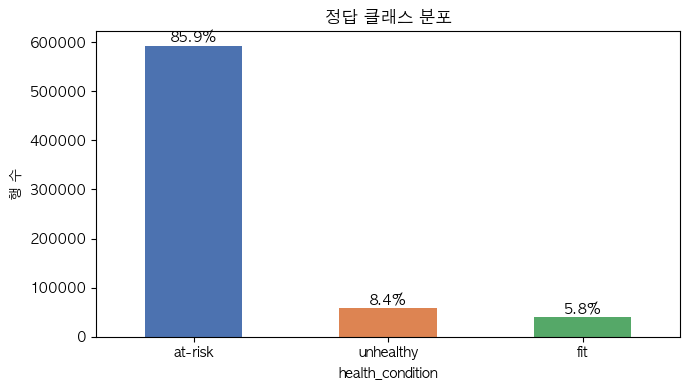

In [6]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "AppleGothic"   # 한글 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

counts = train["health_condition"].value_counts()
ax = counts.plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868"], figsize=(7, 4), rot=0)
for i, v in enumerate(counts):
    ax.text(i, v, f"{v / len(train) * 100:.1f}%", ha="center", va="bottom")
ax.set_title("정답 클래스 분포")
ax.set_ylabel("행 수")
plt.tight_layout()
plt.show()

at-risk 85.9 / unhealthy 8.4 / fit 5.8%. 무조건 at-risk라고만 찍어도 정확도 85.9%가 나오는 심한 불균형이다. 이 사실이 뒤에서 점수 착시의 발단이 된다.

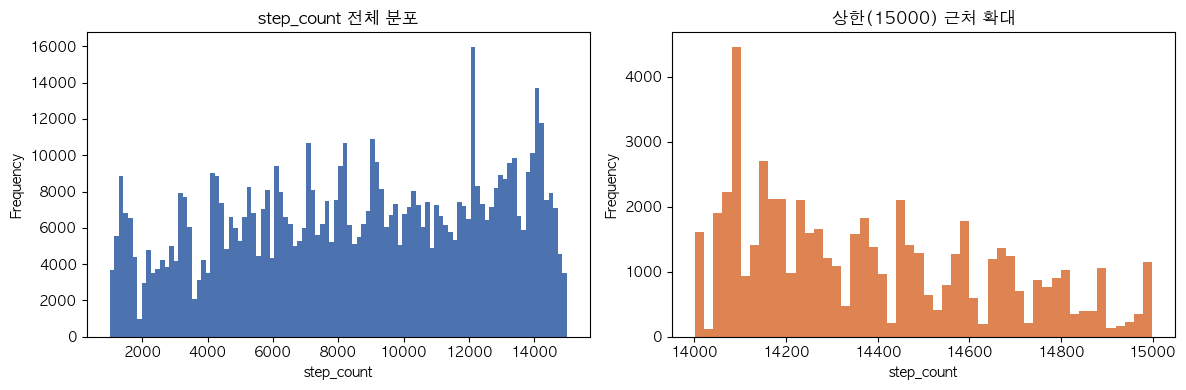

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train["step_count"].plot(kind="hist", bins=100, ax=axes[0], color="#4C72B0")
axes[0].set_title("step_count 전체 분포")
axes[0].set_xlabel("step_count")

train.loc[train["step_count"] > 14000, "step_count"].plot(kind="hist", bins=50, ax=axes[1], color="#DD8452")
axes[1].set_title("상한(15000) 근처 확대")
axes[1].set_xlabel("step_count")
plt.tight_layout()
plt.show()

왼쪽에서 분포가 1000에서 칼같이 시작하고 오른쪽 확대에서 15000 직전 막대가 치솟는다. 수치로 잰 하한·상한 클리핑이 그림에서도 그대로 보인다.

### EDA 정리

- 690,088행, 15컬럼. 카테고리 3등분과 클리핑 흔적으로 보아 합성 데이터로 추정.
- 정답 분포 at-risk 85.9 / unhealthy 8.4 / fit 5.8%로 심한 불균형. "무조건 at-risk" 기준선의 정확도가 85.9%.
- 결측치는 id 빼고 전 컬럼에 1~12%. 다 지우면 절반만 남으니 지우지 않고 채운다.
- step_count는 인위적으로 범위가 제한된 값(하한 1000 확실, 상한 15000 추정).
- 다음 결정: 결측치를 무엇으로 채울지. 컬럼 성격을 보고 판단한다.

## 3. 전처리 — 채우기 방법을 정하고 글자를 숫자로

숫자형은 평균과 중앙값을 실제로 비교했다. 둘이 거의 일치한다(heart_rate 75.10 vs 75.10, 차이가 제일 큰 step_count도 8616 vs 8856). 원칙적으로는 둘 다 채워보고 결과를 비교하는 게 맞지만 차이가 이 정도면 최종 성능 차이도 노이즈 수준일 가능성이 커서 평균으로 정했다.

범주형은 카테고리 비율이 균등해 최빈값의 이점이 적고 결측 자체가 응답 회피 같은 신호일 수 있다는 이유로 "missing"이라는 새 카테고리로 채우기로 했다.

In [8]:
# 범주형 결측치 -> "missing"이라는 새 카테고리로 채우기
for col in categorical_cols:
    train[col] = train[col].fillna("missing")

# 숫자형 결측치 -> 평균으로 채우기
for col in numeric_cols:
    train[col] = train[col].fillna(train[col].mean())

# 다 채워졌는지 확인
train.isnull().sum()

id                         0
health_condition           0
sleep_duration             0
heart_rate                 0
bmi                        0
calorie_expenditure        0
step_count                 0
exercise_duration          0
water_intake               0
diet_type                  0
stress_level               0
sleep_quality              0
physical_activity_level    0
smoking_alcohol            0
gender                     0
dtype: int64

### 인코딩 — 글자를 숫자로

모델은 글자(veg, male 같은 값)를 못 읽는다. 첫 기준선이라 단순하게 간다. stress_level처럼 순서가 있는 컬럼도 구분하지 않고 범주형 전부를 원핫 인코딩(각 값마다 O/X 컬럼 생성)으로 처리했다. 순서를 살리는 인코딩은 개선 여지로 남겨뒀다.

In [9]:
# 범주형 컬럼 원핫 인코딩 (id, 정답 컬럼은 빼고)
X = pd.get_dummies(train.drop(columns=["id", "health_condition"]))
y = train["health_condition"]

print(X.shape)
X.head()

(690088, 31)


,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type_balanced,diet_type_missing,diet_type_non-veg,...,physical_activity_level_moderate,physical_activity_level_sedentary,smoking_alcohol_missing,smoking_alcohol_no,smoking_alcohol_occasional,smoking_alcohol_yes,gender_female,gender_male,gender_missing,gender_other
0,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,False,False,False,...,False,True,False,False,False,True,True,False,False,False
1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,False,False,True,...,True,False,False,False,False,True,False,False,False,True
2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,False,False,False,...,False,False,False,False,False,True,False,True,False,False
3,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,False,False,False,...,False,False,False,False,True,False,True,False,False,False
4,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,False,False,False,...,False,True,True,False,False,False,False,True,False,False


## 4. 첫 모델 — 검증 정확도 96.6%

데이터가 69만 행이라 5번 교차검증을 쓰면 학습을 5번 반복해서 너무 오래 걸린다. 첫 확인은 train/validation을 한 번만 나눠 빠르게 본다. `stratify=y`를 쓰는 이유: 정답이 86 / 8 / 6%로 불균형이라 무작위로 나누면 validation 쪽에 소수 클래스가 너무 적게(또는 많이) 몰릴 수 있다. stratify는 나눌 때도 원래 비율을 유지해준다.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

pred = model.predict(X_val)
acc = accuracy_score(y_val, pred)
print("검증 정확도:", round(acc, 4))
print("베이스라인(무조건 at-risk):", round((y_val == "at-risk").mean(), 4))

검증 정확도: 0.9661
베이스라인(무조건 at-risk): 0.8587


### 클래스별로 뜯어보기 — 혼동행렬

검증 정확도 96.61%가 세 클래스를 골고루 맞힌 건지, 다수인 at-risk만 잘 맞힌 건지 확인한다. 행이 실제 정답, 열이 모델 예측이다.

In [11]:
pd.crosstab(y_val, pred, rownames=["실제"], colnames=["예측"])

예측,at-risk,fit,unhealthy
실제,,,
at-risk,117760,423,329
fit,1396,6534,31
unhealthy,2489,15,9041


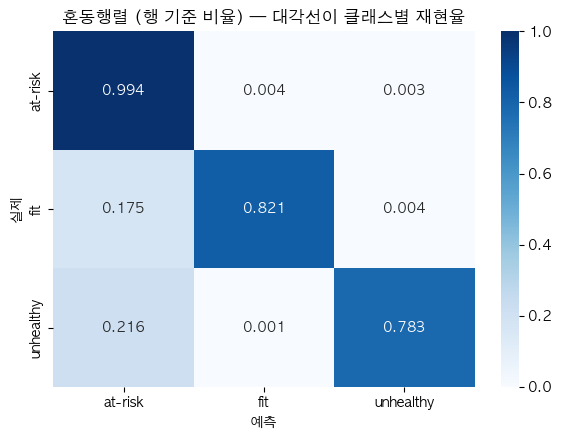

In [12]:
import seaborn as sns

# 행(실제) 기준 비율 = 그 클래스를 놓치지 않고 잡아낸 비율(재현율)
cm = pd.crosstab(y_val, pred, normalize="index")
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1)
plt.title("혼동행렬 (행 기준 비율) — 대각선이 클래스별 재현율")
plt.ylabel("실제")
plt.xlabel("예측")
plt.tight_layout()
plt.show()

at-risk는 99.4%를 잡아내지만 fit은 82%, unhealthy는 78%에 그친다. 전체 정확도 96.6%는 86%를 차지하는 at-risk를 거의 다 맞힌 덕이 크고 소수 클래스는 그만큼 못 잡는다. 이 표가 뒤에서 다시 중요해진다.

### 어떤 단서가 중요했나 — feature importance

랜덤포레스트는 학습하면서 각 단서로 나눴을 때 얼마나 잘 갈렸는지를 기록한다. `feature_importances_`로 그 값을 꺼내 이 데이터에서 실제로 뭐가 세 클래스를 가르는지 확인한다.

In [13]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(15)

sleep_duration                       0.345610
stress_level_high                    0.115895
stress_level_low                     0.087121
stress_level_medium                  0.070466
physical_activity_level_active       0.058193
bmi                                  0.052736
step_count                           0.038189
exercise_duration                    0.037927
calorie_expenditure                  0.029593
heart_rate                           0.027744
water_intake                         0.026739
physical_activity_level_moderate     0.023642
stress_level_missing                 0.018102
physical_activity_level_sedentary    0.015083
sleep_quality_poor                   0.008441
dtype: float64

sleep_duration 혼자 34.6%, stress_level(카테고리 3개 합) 27.4%로 이 둘이 전체의 60% 이상이다. diet_type·gender·smoking_alcohol은 top 15에 없다. 수면시간과 스트레스가 지배적인 두 축이라는 걸 데이터로 확인했다.

## 5. 첫 제출 — 검증 96.6% vs 실제 86.2%

검증이 끝났으니 최종 모델은 데이터 전부로 다시 학습한다(retrain-on-all). test.csv도 train과 똑같이 전처리하되 컬럼 구성을 train과 정확히 맞춘다. `reindex`로 컬럼 순서를 맞추고 test에 없는 카테고리 값은 0으로 채운다.

In [14]:
# test.csv도 train과 똑같이 전처리
test = pd.read_csv("test.csv")

for col in categorical_cols:
    test[col] = test[col].fillna("missing")
for col in numeric_cols:
    test[col] = test[col].fillna(train[col].mean())  # train 기준값으로 채움

X_test = pd.get_dummies(test.drop(columns=["id"]))
X_test = X_test.reindex(columns=X.columns, fill_value=0)  # train 컬럼 구성에 맞춤

# 최종 모델: 데이터 전부로 재학습
final_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
final_model.fit(X, y)

test_pred = final_model.predict(X_test)

submission = pd.DataFrame({"id": test["id"], "health_condition": test_pred})
submission.to_csv("submission.csv", index=False)
submission.head()

,id,health_condition
0,690088,unhealthy
1,690089,at-risk
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


### 실제 점수 0.86217 — 10%p가 사라졌다

캐글 실제 점수는 0.86217. 검증 정확도 96.61%에서 10%p 넘게 떨어졌고 "무조건 at-risk" 기준선(85.87%)과 거의 차이가 없다. 노이즈로 넘길 수준이 아니라서 원인을 추적했다.

**가설 1 — train.csv에 중복 행이 많아 검증이 오염됐다.** 확인하니 중복 행 0개. 기각.

**가설 2 — 과적합.** 훈련 정확도를 재보니 100.0%다. 자기가 배운 데이터는 하나도 안 틀린다는 건 명백한 과적합 신호다(연습문제만 달달 외워 실전에서 헛발질하는 그 현상). 그런데 과적합이 10%p 격차를 다 설명하는지는 별개 문제라서 max_depth를 바꿔가며 실험했다.

In [15]:
# max_depth별 훈련/검증 정확도 비교 (과적합 확인)
for depth in [4, 6, 8, 10, None]:
    m = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42, n_jobs=-1)
    m.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, m.predict(X_train))
    val_acc = accuracy_score(y_val, m.predict(X_val))
    print(f"max_depth={depth}: 훈련={train_acc:.4f}, 검증={val_acc:.4f}, 차이={train_acc - val_acc:.4f}")

max_depth=4: 훈련=0.8841, 검증=0.8840, 차이=0.0001


max_depth=6: 훈련=0.9451, 검증=0.9460, 차이=-0.0009


max_depth=8: 훈련=0.9634, 검증=0.9637, 차이=-0.0002


max_depth=10: 훈련=0.9649, 검증=0.9648, 차이=0.0000


max_depth=None: 훈련=1.0000, 검증=0.9661, 차이=0.0339


depth=10은 훈련≈검증(96.49 vs 96.48%)으로 과적합이 거의 없는데도 검증 정확도가 제한없음 모델(96.61%)과 0.13%p밖에 차이가 안 난다. 과적합으로 얻은 이득이 검증 기준 0.13%p뿐이라면 실제 점수 10%p 추락을 과적합만으로 설명하기 어렵다.

짐작으로 결론 내리지 않고 depth=10 모델을 실제로 제출해봤다. 결과는 0.83799. 과적합을 거의 없앤 모델이 과적합 있는 모델(0.86217)보다 오히려 더 나쁘다. 과적합이 주 원인이라는 가설로는 설명이 안 되는 결과다.

### 남은 가설 둘 — 누수는 기각, 지표가 정답이었다

**가설 3 — 파이프라인을 안 써서 생긴 데이터 누수.** 코드를 다시 보니 숫자형 결측치를 평균으로 채우는 시점이 train_test_split보다 먼저다. validation으로 빠질 20%도 평균 계산에 섞였으니 엄밀히는 누수가 실제로 있다. 그래도 기각했다. 이유는 두 가지다. 결측이 1~12%뿐이라 평균값 자체가 val 포함 여부로 거의 안 바뀌어서 10%p대 격차를 만들 수 없고, 이 누수는 트리 깊이와 무관하게 항상 같은 방식으로 작동하는데 우리가 본 현상은 깊이를 줄이면 격차가 커지는 것이라 설명이 안 된다.

**가설 4 — 검증에 쓴 지표가 채점 지표와 다르다.** 대회 페이지 Evaluation 탭을 열어 확인했다. 이 대회는 accuracy가 아니라 balanced accuracy로 채점된다. 클래스별 재현율(그 클래스를 놓치지 않고 잡아낸 비율)을 구해 데이터 비율을 무시하고 세 클래스를 똑같은 비중으로 평균 낸 값이다. 지금까지 검증에 쓴 건 전부 accuracy였다. at-risk가 86%인 데이터에서 accuracy는 다수 클래스만 잘 맞혀도 쉽게 올라간다.

이 가설은 depth=10 결과와 방향이 맞는다. 트리가 얕아지면 예측이 다수 클래스 쪽으로 더 쏠려서 accuracy는 유지되지만 소수 클래스 재현율이 떨어져 balanced accuracy는 나빠질 수 있다. 실제 관찰(제한없음 0.862 > depth=10 0.838)과 일치하는 방향이다.

대회 채점 방식은 첫날 Evaluation 탭에서 확인하는 게 정석인데 늦게 확인해서 가설 세 개를 거친 뒤에야 도달했다.

### 같은 지표로 다시 재기 — 파이프라인 재구축

말로 추리만 하지 않고 실측으로 확인한다. EDA와 결측치 채우기 방법은 그대로 두고 실행 코드만 파이프라인 구조로 새로 짠다. 가설 3에서 확인한 누수도 이 참에 구조적으로 없앤다. 채점은 balanced_accuracy_score로 한다.

주의: train 변수는 이미 위에서 fillna로 덮어써졌으니 train.csv를 원본 그대로 새로 불러오는 것부터 시작한다.

In [16]:
# train.csv를 원본 그대로 새로 불러옴 (위 train 변수는 이미 fillna로 덮어써졌으니까)
train_raw = pd.read_csv("train.csv")
print("결측치 다시 있는지 확인:")
print(train_raw.isnull().sum())

결측치 다시 있는지 확인:
id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64


In [17]:
# 전처리 조립법(preprocessor) 만들기 - 아직 데이터에 적용은 안 함, 설계도만
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# 범주형 컬럼: 빈칸 -> "missing" -> 원핫인코딩
categorical_pipeline = Pipeline([
    ("결측치_채우기", SimpleImputer(strategy="constant", fill_value="missing")),
    ("원핫인코딩", OneHotEncoder(handle_unknown="ignore")),
])

# 숫자형 컬럼: 빈칸 -> 평균
numeric_pipeline = Pipeline([
    ("결측치_채우기", SimpleImputer(strategy="mean")),
])

# 컬럼 묶음마다 다른 처리 적용
preprocessor = ColumnTransformer([
    ("범주형", categorical_pipeline, categorical_cols),
    ("숫자형", numeric_pipeline, numeric_cols),
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('범주형', ...), ('숫자형', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [18]:
# 전처리 + 모델을 하나의 파이프라인으로 묶기
full_pipeline = Pipeline([
    ("전처리", preprocessor),
    ("모델", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
])

X = train_raw.drop(columns=["id", "health_condition"])
y = train_raw["health_condition"]

# split을 먼저 함 - 이 시점엔 아직 아무 통계도 계산 안 됨
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# fit은 X_train에만 함 - 파이프라인 안 SimpleImputer 평균도 train에서만 배움
full_pipeline.fit(X_train, y_train)
pred = full_pipeline.predict(X_val)

from sklearn.metrics import balanced_accuracy_score

acc_rf = accuracy_score(y_val, pred)
bal_rf = balanced_accuracy_score(y_val, pred)
print("정확도(accuracy):", round(acc_rf, 4))
print("균형 정확도(balanced accuracy):", round(bal_rf, 4))

정확도(accuracy): 0.9662
균형 정확도(balanced accuracy): 0.8662


### 검증 ≈ 실제 — 추적 종결

실행 전 예측: 가설 4가 맞다면 balanced accuracy가 실제 캐글 점수 0.86217에 가깝게 나올 것이다.

결과는 accuracy 0.9662, balanced accuracy 0.8662. 착시가 그대로 재현되고 balanced accuracy는 실제 점수와 0.4%p 차이로 일치한다. 격차의 진짜 원인은 과적합도 누수도 아니고 처음부터 잘못된 지표로 검증한 것이었다. 모델은 처음부터 이 실력(약 0.86)이었고 그동안 본 96%대는 다수 클래스에 눈먼 정확도가 만든 착시였다.

depth 실험도 같은 지표로 다시 읽힌다. depth=10과 제한없음은 accuracy로는 거의 동일(96.48 vs 96.61%)했지만 실제 점수는 0.838 vs 0.862로 2.4%p 차이였다. accuracy로는 안 보이던 진짜 차이가 balanced accuracy에선 보인다. accuracy로 두 모델을 비교했다면 이 차이를 놓쳤을 것이다.

이후 모델 비교·개선 판단은 전부 balanced accuracy 하나로 한다.

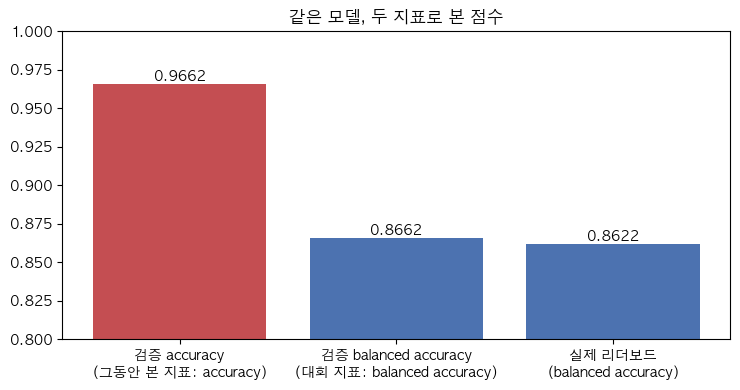

In [19]:
fig, ax = plt.subplots(figsize=(7.5, 4))
bars = ax.bar(
    ["검증 accuracy\n(그동안 본 지표: accuracy)", "검증 balanced accuracy\n(대회 지표: balanced accuracy)", "실제 리더보드\n(balanced accuracy)"],
    [acc_rf, bal_rf, 0.86217],
    color=["#C44E52", "#4C72B0", "#4C72B0"],
)
ax.bar_label(bars, fmt="%.4f")
ax.set_ylim(0.80, 1.00)
ax.set_title("같은 모델, 두 지표로 본 점수")
plt.tight_layout()
plt.show()

왼쪽 지표(accuracy)로 보면 96점, 대회 지표(balanced accuracy)로 보면 86점. 같은 모델이다. 리더보드 점수(0.86217)는 캐글에서 받은 실측값이라 코드 계산이 아니라 기록에서 온 숫자다.

## 6. 개선 실험 — 오버샘플링, 그리고 부스팅

### SMOTE — 소수 클래스를 늘려서 학습

재현율이 낮은 두 클래스(fit 82%, unhealthy 78%)를 SMOTE(소수 클래스와 닮은 합성 데이터를 만들어 늘리는 오버샘플링)로 보강해본다. 원칙: SMOTE는 train에만 적용하고 val은 원본 그대로 둔다. val이 건드리지 않은 진짜 시험이어야 검증이 의미 있다.

sklearn의 Pipeline은 값만 바꾸는 변환만 연결할 수 있다. SMOTE는 행 개수 자체를 늘리는 리샘플링이라 imbalanced-learn의 전용 Pipeline을 쓴다. 이 안에서는 학습할 때만 SMOTE가 작동하고 예측할 땐 자동으로 건너뛴다.

In [20]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# preprocessor는 위에서 이미 만든 것 재사용 - 전처리와 모델 사이에 "오버샘플링" 단계만 끼워넣음
smote_pipeline = ImbPipeline([
    ("전처리", preprocessor),
    ("오버샘플링", SMOTE(random_state=42)),
    ("모델", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
])

smote_pipeline

,steps,"[('전처리', ...), ('오버샘플링', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('범주형', ...), ('숫자형', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The 

In [21]:
smote_pipeline.fit(X_train, y_train)
pred_smote = smote_pipeline.predict(X_val)  # X_val은 원본 그대로 - predict할 땐 SMOTE 단계가 건너뛰어짐
bal_smote = balanced_accuracy_score(y_val, pred_smote)

print("SMOTE 적용 전 balanced accuracy:", round(bal_rf, 4))
print("SMOTE 적용 후 balanced accuracy:", round(bal_smote, 4))

SMOTE 적용 전 balanced accuracy: 0.8662
SMOTE 적용 후 balanced accuracy: 0.8687


0.8662 → 0.8687. 오르긴 했는데 0.25%p로 작다. 단일 holdout 검증에선 이 정도 차이가 운으로 갈릴 수 있다는 한계도 있다(8절 참고).

### 부스팅 3종 — 기본값 비교

XGBoost·LightGBM·CatBoost를 전부 기본값(튜닝 없음)으로, 지금까지 쓰던 전처리를 그대로 붙여 비교한다. 목적은 어느 라이브러리가 낫냐를 정밀하게 가리는 게 아니라 배깅(랜덤포레스트) vs 부스팅의 힘 차이부터 가늠하는 것이다.

판단 기준을 미리 정했다. 기본값끼리 1%p 이상 벌어지면 그 1등만 집중 튜닝하고 1%p 미만이면 상위 후보를 남겨두고 판단을 보류한다.

In [22]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost는 이 버전에서 문자열 정답('at-risk' 등)을 안 받고 0,1,2 숫자만 받음 -> 숫자로 변환
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)

xgb_pipeline = Pipeline([
    ("전처리", preprocessor),
    ("모델", XGBClassifier(random_state=42, n_jobs=-1)),
])
xgb_pipeline.fit(X_train, y_train_enc)
pred_xgb = xgb_pipeline.predict(X_val)
bal_xgb = balanced_accuracy_score(y_val_enc, pred_xgb)
print("XGBoost (기본값) balanced accuracy:", round(bal_xgb, 4))

XGBoost (기본값) balanced accuracy: 0.8803


In [23]:
from lightgbm import LGBMClassifier
import warnings

# 파이프라인 내부에서 numpy 배열로 변환돼 생기는 컬럼명 안내 경고 숨김 (결과에 영향 없음)
warnings.filterwarnings("ignore", message="X does not have valid feature names")

lgbm_pipeline = Pipeline([
    ("전처리", preprocessor),
    ("모델", LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)),
])
lgbm_pipeline.fit(X_train, y_train)
pred_lgbm = lgbm_pipeline.predict(X_val)
bal_lgbm = balanced_accuracy_score(y_val, pred_lgbm)
print("LightGBM (기본값) balanced accuracy:", round(bal_lgbm, 4))

LightGBM (기본값) balanced accuracy: 0.8749


In [24]:
from catboost import CatBoostClassifier

cat_pipeline = Pipeline([
    ("전처리", preprocessor),
    ("모델", CatBoostClassifier(random_state=42, verbose=0)),
])
cat_pipeline.fit(X_train, y_train)
pred_cat = cat_pipeline.predict(X_val).ravel()  # catboost는 (n,1) 모양으로 반환해서 1차원으로 펴줌
bal_cat = balanced_accuracy_score(y_val, pred_cat)
print("CatBoost (기본값) balanced accuracy:", round(bal_cat, 4))

CatBoost (기본값) balanced accuracy: 0.8786


In [25]:
print("=== 기본값 비교 (balanced accuracy, 같은 val 세트) ===")
print("랜덤포레스트 (SMOTE 없음):", round(bal_rf, 4))
print("랜덤포레스트 + SMOTE:     ", round(bal_smote, 4))
print("XGBoost (기본값):        ", round(bal_xgb, 4))
print("LightGBM (기본값):       ", round(bal_lgbm, 4))
print("CatBoost (기본값):       ", round(bal_cat, 4))

=== 기본값 비교 (balanced accuracy, 같은 val 세트) ===
랜덤포레스트 (SMOTE 없음): 0.8662
랜덤포레스트 + SMOTE:      0.8687
XGBoost (기본값):         0.8803
LightGBM (기본값):        0.8749
CatBoost (기본값):        0.8786


부스팅 셋 다 랜덤포레스트(0.8662~0.8687)를 확실히 이긴다. XGBoost 0.8803 > CatBoost 0.8786 > LightGBM 0.8749. 부스팅끼리 격차는 제일 큰 것도 0.54%p로 미리 정한 기준(1%p) 미만이라 승자를 못 정했다.

그런데 이 비교엔 약점이 있다. 각 라이브러리의 특수 능력(XGBoost의 결측치 자동 학습, CatBoost의 범주형 자동 처리)을 꺼놓고 우리가 만든 원핫·평균대체 전처리를 똑같이 통과시킨 손발 묶은 비교라고 같이 공부하는 AI가 짚었다. 맞는 지적이다. 그 능력들이 각 라이브러리가 실전에서 강한 이유인데 꺼놓고 비교하면 실제로 뭘 써야 하나라는 질문에 답이 안 된다. 각자 네이티브 방식으로 다시 비교한다.

### 네이티브 능력을 켜고 재비교

전처리기 없이 각 라이브러리에 맞는 최소 준비만 한다.

- XGBoost·LightGBM: 범주형 컬럼을 원핫 대신 `category` dtype으로 넘긴다(자체적으로 범주 인식). 결측치는 채우지 않고 그대로 둔다(둘 다 자동 처리).
- CatBoost: 원본 그대로 두고 `cat_features` 파라미터로 범주형 컬럼만 알려준다. 단 범주형 결측치는 문자열을 요구해서 EDA 때 정한 "missing" 채우기를 재사용한다.

In [26]:
# XGBoost/LightGBM용 - 범주형 컬럼만 category dtype으로 변환 (결측치는 그대로 둠)
X_train_native = X_train.copy()
X_val_native = X_val.copy()
for col in categorical_cols:
    X_train_native[col] = X_train_native[col].astype("category")
    X_val_native[col] = X_val_native[col].astype("category")

X_train_native.dtypes

sleep_duration              float64
heart_rate                  float64
bmi                         float64
calorie_expenditure         float64
step_count                  float64
exercise_duration           float64
water_intake                float64
diet_type                  category
stress_level               category
sleep_quality              category
physical_activity_level    category
smoking_alcohol            category
gender                     category
dtype: object

In [27]:
# XGBoost 네이티브: enable_categorical=True로 category 컬럼 자체 인식 + 결측치 자동학습
xgb_native = XGBClassifier(random_state=42, n_jobs=-1, enable_categorical=True, tree_method="hist")
xgb_native.fit(X_train_native, y_train_enc)
pred_xgb_native = xgb_native.predict(X_val_native)
bal_xgb_native = balanced_accuracy_score(y_val_enc, pred_xgb_native)
print("XGBoost (네이티브) balanced accuracy:", round(bal_xgb_native, 4))

XGBoost (네이티브) balanced accuracy: 0.8819


In [28]:
# LightGBM 네이티브: category 컬럼 자동 인식 + 결측치 자동학습
lgbm_native = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
lgbm_native.fit(X_train_native, y_train)
pred_lgbm_native = lgbm_native.predict(X_val_native)
bal_lgbm_native = balanced_accuracy_score(y_val, pred_lgbm_native)
print("LightGBM (네이티브) balanced accuracy:", round(bal_lgbm_native, 4))

LightGBM (네이티브) balanced accuracy: 0.8739


In [29]:
# CatBoost는 범주형 컬럼의 결측치(NaN)를 문자열로 요구함 (숫자 컬럼 결측치는 그대로 둬도 됨 - 자동 처리)
# EDA 때 이미 내린 결정 재사용: 범주형 결측 -> "missing" 카테고리
X_train_cat = X_train.copy()
X_val_cat = X_val.copy()
for col in categorical_cols:
    X_train_cat[col] = X_train_cat[col].fillna("missing")
    X_val_cat[col] = X_val_cat[col].fillna("missing")

cat_native = CatBoostClassifier(random_state=42, verbose=0, cat_features=categorical_cols)
cat_native.fit(X_train_cat, y_train)
pred_cat_native = cat_native.predict(X_val_cat).ravel()
bal_cat_native = balanced_accuracy_score(y_val, pred_cat_native)
print("CatBoost (네이티브) balanced accuracy:", round(bal_cat_native, 4))

CatBoost (네이티브) balanced accuracy: 0.8757


In [30]:
results = {
    "랜덤포레스트": bal_rf,
    "랜덤포레스트 + SMOTE": bal_smote,
    "XGBoost (전처리 통일)": bal_xgb,
    "LightGBM (전처리 통일)": bal_lgbm,
    "CatBoost (전처리 통일)": bal_cat,
    "XGBoost (네이티브)": bal_xgb_native,
    "LightGBM (네이티브)": bal_lgbm_native,
    "CatBoost (네이티브)": bal_cat_native,
}
print("=== 전체 비교 (balanced accuracy) ===")
for name, score in results.items():
    print(f"{name:<20} {score:.4f}")

=== 전체 비교 (balanced accuracy) ===
랜덤포레스트               0.8662
랜덤포레스트 + SMOTE       0.8687
XGBoost (전처리 통일)     0.8803
LightGBM (전처리 통일)    0.8749
CatBoost (전처리 통일)    0.8786
XGBoost (네이티브)       0.8819
LightGBM (네이티브)      0.8739
CatBoost (네이티브)      0.8757


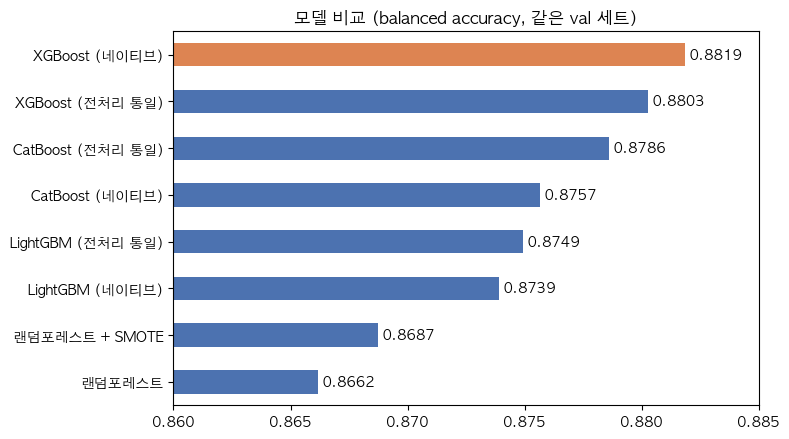

In [31]:
s = pd.Series(results).sort_values()
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#DD8452" if name == "XGBoost (네이티브)" else "#4C72B0" for name in s.index]
s.plot(kind="barh", ax=ax, color=colors)
ax.set_xlim(0.86, 0.885)
for i, v in enumerate(s):
    ax.text(v, i, f" {v:.4f}", va="center")
ax.set_title("모델 비교 (balanced accuracy, 같은 val 세트)")
plt.tight_layout()
plt.show()

### 판정 — 네이티브가 항상 낫진 않았다

예상과 반대로 네이티브 모드에서 XGBoost만 좋아지고(0.8803 → 0.8819) LightGBM·CatBoost는 살짝 나빠졌다(0.8749 → 0.8739, 0.8786 → 0.8757). 특수 능력을 켜는 게 항상 낫다는 가정이 이 데이터에선 안 맞는다.

짐작(미검증): 이 데이터의 범주형은 컬럼마다 값이 3~4개뿐인 저카디널리티다. 범주형 자동 처리는 범주가 수백~수천 개일 때 이득이 큰데 이렇게 적으면 원핫 인코딩도 이미 충분해서 특수 처리가 득이 안 될 수 있다. 확인하려면 고카디널리티 데이터로 대조 실험이 필요한데 지금은 하지 않는다.

확실한 결론: 부스팅(0.874~0.882) vs 랜덤포레스트(0.866~0.869)의 격차 1~1.6%p는 신뢰할 만하다. 부스팅끼리 격차(최대 0.8%p)는 여전히 애매해서 진짜 1등은 단정 못 한다. 현재 1위는 XGBoost(네이티브) 0.8819.

## 7. 최종 제출 — XGBoost(네이티브)

검증에서 제일 좋았던 XGBoost(네이티브, 0.8819)로 제출한다. 검증은 끝났으니 데이터 전부로 재학습(retrain-on-all)하고 test.csv를 예측한다.

In [32]:
# 데이터 전부로 재학습 (X, y = train_raw 전체, 검증 없이 다 씀)
X_native_full = X.copy()
for col in categorical_cols:
    X_native_full[col] = X_native_full[col].astype("category")
y_full_enc = le.transform(y)  # le는 위에서 이미 3개 클래스 다 fit된 상태

final_xgb = XGBClassifier(random_state=42, n_jobs=-1, enable_categorical=True, tree_method="hist")
final_xgb.fit(X_native_full, y_full_enc)
print("재학습 완료, 학습 데이터 크기:", X_native_full.shape)

재학습 완료, 학습 데이터 크기: (690088, 13)


In [33]:
# test.csv 새로 불러와서(결측치 안 채움, 그대로) 범주형만 category dtype으로
test_raw = pd.read_csv("test.csv")
X_test_native = test_raw.drop(columns=["id"]).copy()
for col in categorical_cols:
    X_test_native[col] = X_test_native[col].astype("category")
X_test_native = X_test_native.reindex(columns=X.columns)

test_pred_enc = final_xgb.predict(X_test_native)
test_pred = le.inverse_transform(test_pred_enc)  # 숫자 -> 'at-risk' 같은 원래 글자로

submission = pd.DataFrame({"id": test_raw["id"], "health_condition": test_pred})
submission.to_csv("submission.csv", index=False)
submission.head()

,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


### 결과 — 0.87828, 신기록

캐글 실제 점수 0.87828.

- 검증 0.8819 → 실제 0.87828로 차이가 0.36%p다. accuracy로 검증하던 때 10%p 넘게 벌어졌던 것과 비교하면 검증이 실전을 잘 예측한다. 지표를 고친 효과가 실측으로 확인됐다.
- 기존 최고 0.86217(랜덤포레스트)에서 1.6%p 개선.

## 8. 마무리

### 배운 것

1. 로컬 검증은 리더보드와 같은 지표로 잰다. 이 대회의 10%p 격차는 과적합도 누수도 아니고 지표(accuracy vs balanced accuracy)가 달랐던 것이다.
2. 잘못된 지표로는 모델 비교도 틀린다. depth=10과 제한없음은 accuracy로 0.13%p 차이였지만 실제 점수로는 2.4%p 차이였다.
3. 불균형 데이터에서 accuracy는 다수 클래스만 맞혀도 올라간다. 혼동행렬로 클래스별 재현율을 봐야 실제 실력이 보인다.
4. 개선 폭은 오버샘플링(+0.25%p)보다 모델 교체(부스팅, +1.6%p)가 컸다.
5. 라이브러리의 네이티브 능력이 항상 더 낫진 않다. 켜보고 재는 것까지가 비교다.

### 안 통한 것, 작았던 것

- max_depth=10 (과적합 제거): 실제 점수 0.83799로 오히려 하락. 얕은 트리가 다수 클래스 쪽으로 쏠린 탓.
- SMOTE: 0.8662 → 0.8687 (+0.25%p). 단일 holdout의 노이즈 범위일 수 있다.
- LightGBM·CatBoost 네이티브 모드: 전처리 통일 대비 하락.

### 한계와 다음 과제

- 이 노트북의 검증은 단일 holdout 한 겹이다. 0.8662가 리더보드와 맞은 게 운일 가능성을 배제하려면 StratifiedKFold 교차검증으로 폴드 평균±표준편차를 봐야 한다. 다음 과제.
- 하이퍼파라미터 튜닝을 아직 안 했다. 부스팅 3종의 진짜 순위는 튜닝 후에야 가려진다.